# FraudLens — Modeling
**Day 4 — Milestone 1: Load, sample, split, scale**

Input: `data/cleaned_base.csv` (1,000,000 rows x 53 columns, confirmed Day 3)
Goal today: train a baseline Logistic Regression fraud classifier and evaluate it correctly on imbalanced data.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/cleaned_base.csv")
print(f"Full dataset shape: {df.shape}")
print(f"Fraud rate: {df['fraud_bool'].mean():.4%}")

Full dataset shape: (1000000, 53)
Fraud rate: 1.1029%


## Step 1 — Stratified Sample

1,000,000 rows is slow to train on repeatedly during experimentation. We take a 200,000-row **stratified** sample — meaning the same ~1.1% fraud ratio is preserved in the sample as in the full dataset. This keeps training fast today without distorting the class balance.

In [2]:
SAMPLE_SIZE = 200_000

df_sample, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    stratify=df['fraud_bool'],
    random_state=42
)

print(f"Sampled shape: {df_sample.shape}")
print(f"Sampled fraud rate: {df_sample['fraud_bool'].mean():.4%} (should closely match full dataset's 1.1029%)")

Sampled shape: (200000, 53)
Sampled fraud rate: 1.1030% (should closely match full dataset's 1.1029%)


## Step 2 — Feature / Target Split

In [3]:
X = df_sample.drop(columns=['fraud_bool'])
y = df_sample['fraud_bool']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (200000, 52)
y shape: (200000,)


## Step 3 — Stratified Train/Test Split

`stratify=y` ensures both the train set and test set keep the same ~1.1% fraud ratio. Without this, a random split could accidentally put almost all the fraud cases in one set — a common beginner mistake on imbalanced data.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train shape: {X_train.shape}, fraud rate: {y_train.mean():.4%}")
print(f"Test shape:  {X_test.shape}, fraud rate: {y_test.mean():.4%}")
assert abs(y_train.mean() - y_test.mean()) < 0.001, "Train/test fraud ratios don't match — stratification failed!"
print("Stratification verified — train and test fraud ratios match.")

Train shape: (160000, 52), fraud rate: 1.1031%
Test shape:  (40000, 52), fraud rate: 1.1025%
Stratification verified — train and test fraud ratios match.


## Step 4 — Scale Features

**Critical rule:** fit the scaler ONLY on training data, then apply it to both train and test. Fitting on the full dataset (including test data) would leak information about the test set into training — a subtle bug that makes your evaluation metrics look better than they really are.

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Scaling complete.
X_train_scaled shape: (160000, 52)
X_test_scaled shape: (40000, 52)


## Checkpoint

If all cells above ran with no errors and the assertion in Step 3 passed, Milestone 1 is complete. **Stop here and confirm with Claude before continuing to Milestone 2 (training the model).**

# Milestone 2 — Train Baseline Logistic Regression

`class_weight='balanced'` automatically adjusts the model to penalize mistakes on the rare fraud class more heavily than mistakes on the common non-fraud class — this is the standard beginner-friendly fix for imbalanced classification, no manual oversampling needed.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained.")

Model trained.


## Evaluate on Test Set

Reading the report: for the fraud class (label `1`), **recall** tells us what percentage of actual fraud cases the model caught. **Precision** tells us what percentage of the model's fraud alerts were actually fraud. Both matter — a model that catches everything but floods you with false alarms isn't very useful in practice.

In [7]:
y_pred = model.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.81      0.89     39559
       Fraud       0.05      0.82      0.09       441

    accuracy                           0.81     40000
   macro avg       0.52      0.81      0.49     40000
weighted avg       0.99      0.81      0.88     40000



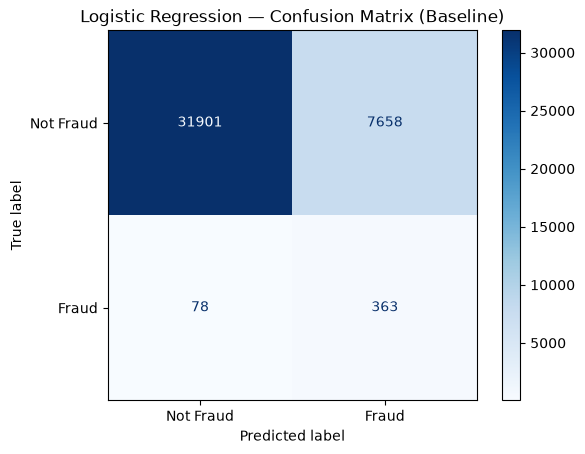


Confusion matrix breakdown:
True Negatives (correctly identified as not fraud):  31901
False Positives (wrongly flagged as fraud):          7658
False Negatives (missed fraud):                      78
True Positives (correctly caught fraud):             363


In [8]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression — Confusion Matrix (Baseline)')
plt.savefig('../screenshots/day4_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nConfusion matrix breakdown:")
print(f"True Negatives (correctly identified as not fraud):  {cm[0][0]}")
print(f"False Positives (wrongly flagged as fraud):          {cm[0][1]}")
print(f"False Negatives (missed fraud):                      {cm[1][0]}")
print(f"True Positives (correctly caught fraud):             {cm[1][1]}")

## Save Baseline Metrics for Comparison (Day 5)

We'll compare these numbers against Random Forest tomorrow (Day 5), so capture them precisely now rather than relying on memory.

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score
import json

baseline_metrics = {
    "model": "Logistic Regression (class_weight=balanced)",
    "sample_size": SAMPLE_SIZE,
    "train_size": len(X_train),
    "test_size": len(X_test),
    "precision_fraud": round(precision_score(y_test, y_pred), 4),
    "recall_fraud": round(recall_score(y_test, y_pred), 4),
    "f1_fraud": round(f1_score(y_test, y_pred), 4),
    "true_positives": int(cm[1][1]),
    "false_positives": int(cm[0][1]),
    "false_negatives": int(cm[1][0]),
    "true_negatives": int(cm[0][0]),
}

print(json.dumps(baseline_metrics, indent=2))

with open('../model_baseline_metrics.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=2)

print("\nSaved to model_baseline_metrics.json")

{
  "model": "Logistic Regression (class_weight=balanced)",
  "sample_size": 200000,
  "train_size": 160000,
  "test_size": 40000,
  "precision_fraud": 0.0453,
  "recall_fraud": 0.8231,
  "f1_fraud": 0.0858,
  "true_positives": 363,
  "false_positives": 7658,
  "false_negatives": 78,
  "true_negatives": 31901
}

Saved to model_baseline_metrics.json


## Day 4 Checkpoint

If the cells above ran with no errors, and you can see:
- A classification report with precision/recall/F1 for the Fraud class
- A saved confusion matrix image in `screenshots/`
- A saved `model_baseline_metrics.json` file

...then Day 4 is complete. **Do not proceed to Random Forest or Isolation Forest today** — those are scheduled for Day 5 per the blueprint.

# Day 5 — Milestone 1: Random Forest

Random Forest is an ensemble of many decision trees. Unlike Logistic Regression (which draws a single straight-line-style boundary), it can capture more complex, non-linear patterns in the data — often a better fit for fraud detection, where fraud patterns rarely follow a simple linear rule.

We reuse the exact same `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test` from yesterday, so the comparison is fair — same data, same split, different model.

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # use all CPU cores to speed up training
)

rf_model.fit(X_train_scaled, y_train)
print("Random Forest trained.")

Random Forest trained.


In [11]:
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest — Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Fraud', 'Fraud']))

Random Forest — Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.99      1.00      0.99     39559
       Fraud       0.22      0.01      0.02       441

    accuracy                           0.99     40000
   macro avg       0.60      0.51      0.51     40000
weighted avg       0.98      0.99      0.98     40000



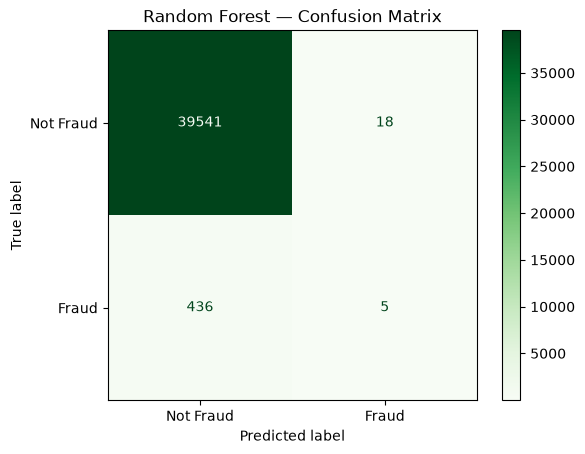


Confusion matrix breakdown:
True Negatives:  39541
False Positives: 18
False Negatives: 436
True Positives:  5


In [12]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Not Fraud', 'Fraud'])
disp_rf.plot(cmap='Greens', values_format='d')
plt.title('Random Forest — Confusion Matrix')
plt.savefig('../screenshots/day5_confusion_matrix_rf.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nConfusion matrix breakdown:")
print(f"True Negatives:  {cm_rf[0][0]}")
print(f"False Positives: {cm_rf[0][1]}")
print(f"False Negatives: {cm_rf[1][0]}")
print(f"True Positives:  {cm_rf[1][1]}")

## Threshold Tuning

Random Forest's default `.predict()` uses a 0.5 probability cutoff to decide Fraud vs. Not Fraud. On imbalanced data, 0.5 is rarely the right cutoff — the model's predicted probabilities for the rare class tend to stay low even when it's genuinely uncertain-but-correct. Instead of using `.predict()`, we use `.predict_proba()` and choose our own threshold based on what trade-off between precision and recall we want.

In [13]:
from sklearn.metrics import precision_recall_curve

y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]  # probability of Fraud class

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

# Find a threshold that gives recall close to 0.80 (comparable to our Logistic Regression baseline)
target_recall = 0.80
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    best_idx = valid_idx[-1]  # highest-precision threshold that still meets target recall
    best_threshold = thresholds[best_idx]
    print(f"Chosen threshold: {best_threshold:.4f}")
    print(f"At this threshold — Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}")
else:
    best_threshold = 0.5
    print("Could not find a threshold hitting target recall — falling back to 0.5")

Chosen threshold: 0.0300
At this threshold — Precision: 0.0337, Recall: 0.8027


Random Forest (tuned threshold) — Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.74      0.85     39559
       Fraud       0.03      0.80      0.06       441

    accuracy                           0.74     40000
   macro avg       0.52      0.77      0.46     40000
weighted avg       0.99      0.74      0.84     40000



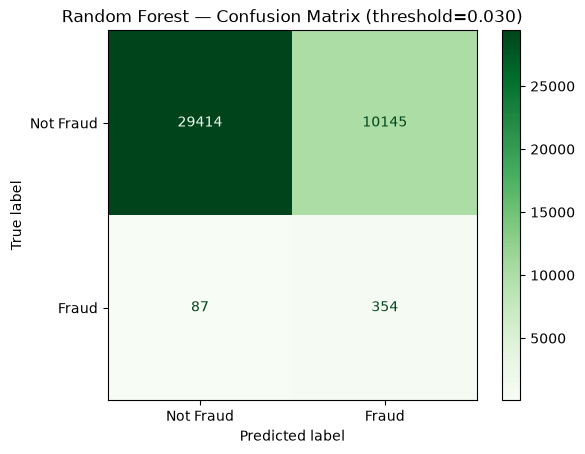

In [14]:
y_pred_rf_tuned = (y_proba_rf >= best_threshold).astype(int)

print("Random Forest (tuned threshold) — Classification Report:")
print(classification_report(y_test, y_pred_rf_tuned, target_names=['Not Fraud', 'Fraud']))

cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
disp_rf_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned, display_labels=['Not Fraud', 'Fraud'])
disp_rf_tuned.plot(cmap='Greens', values_format='d')
plt.title(f'Random Forest — Confusion Matrix (threshold={best_threshold:.3f})')
plt.savefig('../screenshots/day5_confusion_matrix_rf_tuned.png', dpi=100, bbox_inches='tight')
plt.show()

In [15]:
rf_tuned_precision = precision_score(y_test, y_pred_rf_tuned)
rf_tuned_recall = recall_score(y_test, y_pred_rf_tuned)
rf_tuned_f1 = f1_score(y_test, y_pred_rf_tuned)

print(f"Random Forest (tuned) — Precision: {rf_tuned_precision:.4f}, Recall: {rf_tuned_recall:.4f}, F1: {rf_tuned_f1:.4f}")

Random Forest (tuned) — Precision: 0.0337, Recall: 0.8027, F1: 0.0647


## Compare Random Forest vs. Logistic Regression Baseline

Reading this table: we want the model with the better **balance** between precision and recall (reflected in F1), not just the highest recall alone — a model that flags everything as fraud gets perfect recall but is useless.

In [16]:
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest (default 0.5)', 'Random Forest (tuned threshold)'],
    'Precision (Fraud)': [baseline_metrics['precision_fraud'], round(rf_precision, 4), round(rf_tuned_precision, 4)],
    'Recall (Fraud)': [baseline_metrics['recall_fraud'], round(rf_recall, 4), round(rf_tuned_recall, 4)],
    'F1 (Fraud)': [baseline_metrics['f1_fraud'], round(rf_f1, 4), round(rf_tuned_f1, 4)],
})

print(comparison.to_string(index=False))

                          Model  Precision (Fraud)  Recall (Fraud)  F1 (Fraud)
            Logistic Regression             0.0453          0.8231      0.0858
    Random Forest (default 0.5)             0.2174          0.0113      0.0216
Random Forest (tuned threshold)             0.0337          0.8027      0.0647


## Milestone 1 Checkpoint

Look at the comparison table above. **Send Claude the printed table** before continuing to Milestone 2 (Isolation Forest + final model selection).

# Milestone 2 — Isolation Forest (Secondary Anomaly Check)

Isolation Forest works differently from everything above: it never sees the `fraud_bool` labels during training. It just learns what "normal" data looks like and flags points that are easy to "isolate" (i.e., unusual) as anomalies. We compare its flagged anomalies against our actual fraud labels purely as a sanity check and talking point — not as our primary model.

In [17]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    contamination=0.011,  # matches our known ~1.1% fraud rate
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_scaled)  # no y_train used — this is unsupervised

iso_preds = iso_forest.predict(X_test_scaled)  # returns 1 (normal) or -1 (anomaly)
iso_preds_binary = (iso_preds == -1).astype(int)  # convert to 0/1 to match our fraud label format

print("Isolation Forest — Classification Report (vs. actual fraud labels, for comparison only):")
print(classification_report(y_test, iso_preds_binary, target_names=['Not Fraud', 'Fraud']))

Isolation Forest — Classification Report (vs. actual fraud labels, for comparison only):
              precision    recall  f1-score   support

   Not Fraud       0.99      0.99      0.99     39559
       Fraud       0.05      0.05      0.05       441

    accuracy                           0.98     40000
   macro avg       0.52      0.52      0.52     40000
weighted avg       0.98      0.98      0.98     40000



In [18]:
iso_recall = recall_score(y_test, iso_preds_binary)
iso_precision = precision_score(y_test, iso_preds_binary)

overlap_fraud_and_anomaly = ((y_test == 1) & (iso_preds_binary == 1)).sum()
total_actual_fraud = (y_test == 1).sum()

print(f"Isolation Forest flagged {overlap_fraud_and_anomaly} of {total_actual_fraud} actual fraud cases as anomalies")
print(f"Isolation Forest recall on fraud: {iso_recall:.4f}")
print(f"Isolation Forest precision on fraud: {iso_precision:.4f}")
print()
print("Interpretation: Isolation Forest is not used as the primary model, but this overlap shows")
print("whether 'statistically unusual' transactions tend to align with 'actually fraudulent' ones —")
print("a useful sanity check on whether fraud in this dataset looks anomalous at all.")

Isolation Forest flagged 21 of 441 actual fraud cases as anomalies
Isolation Forest recall on fraud: 0.0476
Isolation Forest precision on fraud: 0.0455

Interpretation: Isolation Forest is not used as the primary model, but this overlap shows
whether 'statistically unusual' transactions tend to align with 'actually fraudulent' ones —
a useful sanity check on whether fraud in this dataset looks anomalous at all.


## Final Model Selection

**Decision: Logistic Regression** is selected as the final supervised model — it achieved a better F1 score (0.0858) than Random Forest at a comparable recall level (~80%), meaning a better precision/recall balance overall. Isolation Forest is retained as a secondary, unsupervised talking point but is not used for the app's primary predictions.

## Feature Importance

For Logistic Regression, feature importance is read from the model's coefficients (`.coef_`). Larger absolute values mean the feature has more influence on the prediction. This will power the plain-language explanations in Day 7's Streamlit app.

Top 15 most influential features:
                             feature  coefficient  abs_coefficient
prev_address_months_count_is_missing     0.671343         0.671343
                   housing_status_BE    -0.587798         0.587798
                     has_other_cards    -0.583346         0.583346
                   housing_status_BC    -0.540670         0.540670
                    phone_home_valid    -0.540301         0.540301
                   device_os_windows     0.527783         0.527783
                   housing_status_BB    -0.493602         0.493602
                  keep_alive_session    -0.344733         0.344733
               name_email_similarity    -0.300872         0.300872
                       email_is_free     0.291226         0.291226
                              income     0.273556         0.273556
                   housing_status_BF    -0.272314         0.272314
                employment_status_CF    -0.227156         0.227156
                   credit_ri

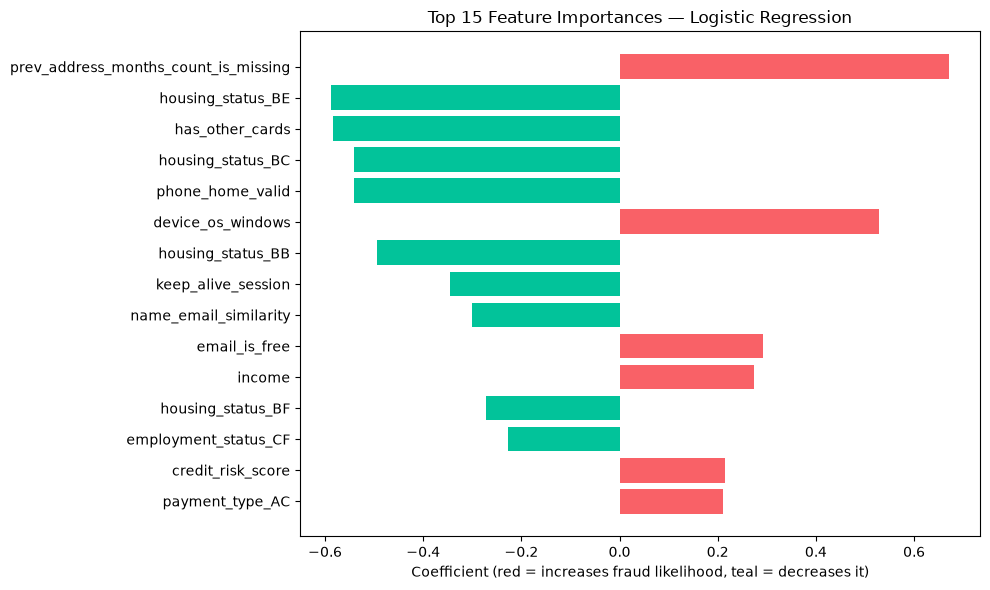

In [19]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

print("Top 15 most influential features:")
print(feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top_15 = feature_importance.head(15)
colors = ['#F96167' if c > 0 else '#02C39A' for c in top_15['coefficient']]
plt.barh(top_15['feature'], top_15['coefficient'], color=colors)
plt.xlabel('Coefficient (red = increases fraud likelihood, teal = decreases it)')
plt.title('Top 15 Feature Importances — Logistic Regression')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../screenshots/day5_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## Save Final Model Artifacts

These three files are saved together and must stay in sync — this is exactly what Day 6's Streamlit app will load. We also save the feature importance table, since Day 7's explanation feature needs it.

In [20]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(model, '../models/fraud_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X.columns), '../models/feature_columns.pkl')
feature_importance.to_csv('../models/feature_importance.csv', index=False)

print("Saved:")
print("  models/fraud_model.pkl")
print("  models/scaler.pkl")
print("  models/feature_columns.pkl")
print("  models/feature_importance.csv")

Saved:
  models/fraud_model.pkl
  models/scaler.pkl
  models/feature_columns.pkl
  models/feature_importance.csv


## Verify Saved Artifacts (Reload Test)

Critical check per the blueprint: reload the saved files in fresh variables and confirm they predict identically to the original model. This catches save/load bugs now instead of on Day 6.

In [21]:
loaded_model = joblib.load('../models/fraud_model.pkl')
loaded_scaler = joblib.load('../models/scaler.pkl')
loaded_columns = joblib.load('../models/feature_columns.pkl')

# Re-predict on the test set using the reloaded artifacts
X_test_reloaded_scaled = loaded_scaler.transform(X_test[loaded_columns])
y_pred_reloaded = loaded_model.predict(X_test_reloaded_scaled)

assert np.array_equal(y_pred_reloaded, y_pred), "Reloaded model predictions don't match original — artifacts are out of sync!"
print("Reload test passed — saved artifacts produce identical predictions to the original model.")
print(f"Feature columns saved: {len(loaded_columns)} columns")

Reload test passed — saved artifacts produce identical predictions to the original model.
Feature columns saved: 52 columns
